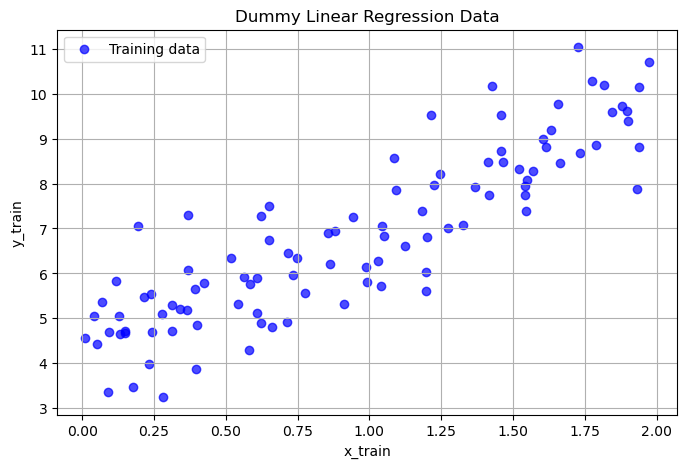

Features shape is: (100, 1)
Target shape is: (100, 1)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Set the seed for reproducibility
np.random.seed(42)

# Number of samples
num_samples = 100

# Generate random x values (features)
x = 2 * np.random.rand(num_samples, 1)

# Generate corresponding y values with a linear relationship (y = 4 + 3x + noise)
true_slope = 3
true_intercept = 4
noise = np.random.randn(num_samples, 1)

y  = true_intercept + true_slope * x + noise

# Plotting the data
plt.figure(figsize = (8, 5))
plt.scatter(x , y , color = "blue", label = "Training data", alpha = 0.7)
plt.title("Dummy Linear Regression Data")
plt.xlabel("x_train")
plt.ylabel("y_train")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape is:", x.shape)
print("Target shape is:", y.shape)


In [12]:
def information_gain(x,y,f_name):
#f_name=0
    thresholds=np.unique(x[:,f_name])
    x_right_branch=[]
    y_right_branch=[]
    x_left_branch=[]
    y_left_branch=[]
    temp_best_x_right=[]
    temp_best_y_right=[]
    temp_best_x_left=[]
    temp_best_y_left=[]
    
    total=len(y)
    unique_classes=np.unique(y)
    n_probs=[]
    

    var_root =np.var(y)
    
    var = 0
    best_threshold=None
    best_var = -np.inf
    
    for n in thresholds:
        if n==thresholds[-1]:
            k=n-0.00001
            left_b_x = x[x[:,f_name]<=k]
            left_b_y = y[x[:,f_name]<=k]
            
            right_b_x = x[x[:,f_name]>k]
            right_b_y = y[x[:,f_name]>k]
        else:    
            left_b_x = x[x[:,f_name]<=n]
            left_b_y = y[x[:,f_name]<=n]
            
            right_b_x = x[x[:,f_name]>n]
            right_b_y = y[x[:,f_name]>n]
            
        x_left_branch.append(left_b_x)
        y_left_branch.append(left_b_y)
        
        x_right_branch.append(right_b_x)
        y_right_branch.append(right_b_y)
        
        left_m = len(left_b_x)
        right_m=len(right_b_x)
        
        left_var = np.var(left_b_y) if len(left_b_y) > 0 else 0
        right_var = np.var(right_b_y) if len(right_b_y) > 0 else 0
        
        var = (len(left_b_y)/total * left_var+len(right_b_y)/total * right_var)
    
        var_reduction = var_root -  var
        if var_reduction > best_var:
            best_var = var_reduction
            best_threshold = n
            temp_best_x_right= right_b_x
            temp_best_y_right= right_b_y
            temp_best_x_left=  left_b_x
            temp_best_y_left=  left_b_y
    return best_threshold, best_var ,[temp_best_x_left,temp_best_x_right ],[temp_best_y_left,temp_best_y_right]

number_classes = len(np.unique(y))
depth=3
best_feature = None
best_x_branchs,best_y_branchs= [x], [y]
nf=len(x[0])

tree = {}##################
root_node = []

for d in range(depth):
    next_x_branches = []
    next_y_branches = []
    
    for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_branchs, best_y_branchs):
        IG_value = -np.inf
        best_feature = None
        temp_best_x_csvs_branch = None
        temp_best_y_csvs_branch = None
        decision = None
        y_pred = None
        best_threshold=None
        for f_name in range(0,nf):
            threshold,IG, x_csvs_branch, y_csvs_branch= information_gain(best_x_csvs_branch, best_y_csvs_branch, f_name)
            print(IG)
            if IG>IG_value:
                IG_value = IG
                if IG>0:
                    temp_best_x_csvs_branch = x_csvs_branch
                    temp_best_y_csvs_branch = y_csvs_branch
                    best_feature = f_name
                    best_threshold=threshold
                else:
                    y_pred = np.mean(best_y_csvs_branch)
        print(best_feature, IG_value)
        node_id = id(best_x_csvs_branch)##################
        root_node.append(node_id)
        tree[node_id] = {             ###################
            "feature": best_feature,
            "ig": IG_value,
            "children": [],
            "threshold":best_threshold,
            "pred" :y_pred,
        } #####################################
        
        if temp_best_x_csvs_branch is not None:
            next_x_branches.extend(temp_best_x_csvs_branch)
            next_y_branches.extend(temp_best_y_csvs_branch)

            for child_x in temp_best_x_csvs_branch: ###########
                tree[node_id]["children"].append(id(child_x))    ###########
            
    best_x_branchs = next_x_branches
    best_y_branchs = next_y_branches
    if d == depth-1:
        for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_branchs, best_y_branchs):
            y_pred = np.mean(best_y_csvs_branch)
            node_id = id(best_x_csvs_branch)##################
            tree[node_id] = {             ###################
                "feature": None,
                "ig": None,
                "children": [],
                "pred": y_pred
            } #####################################
y_pred = []
for i in range(len(x)):
    nid = root_node[0]
    while 1:
        search = tree[nid]["feature"]
        if search is not None :
            feature_name = search
            value=x[i,feature_name]
            if value<=tree[nid]["threshold"]:
                children_id=0
            else:
                children_id=1
            nid = tree[nid]["children"][children_id]
        else:
            y_pred.append(tree[nid]["pred"])
            break
y_true_labels = y

mse = np.mean((y_true_labels - np.array(y_pred))**2)
print("MSE:", mse)  


2.3361005207533037
0 2.3361005207533037
0.46883163026747576
0 0.46883163026747576
0.3611335666392158
0 0.3611335666392158
0.1073290913070275
0 0.1073290913070275
0.12389284386348842
0 0.12389284386348842
0.09554808921810365
0 0.09554808921810365
0.11684302733443785
0 0.11684302733443785
MSE: 6.373401798951209


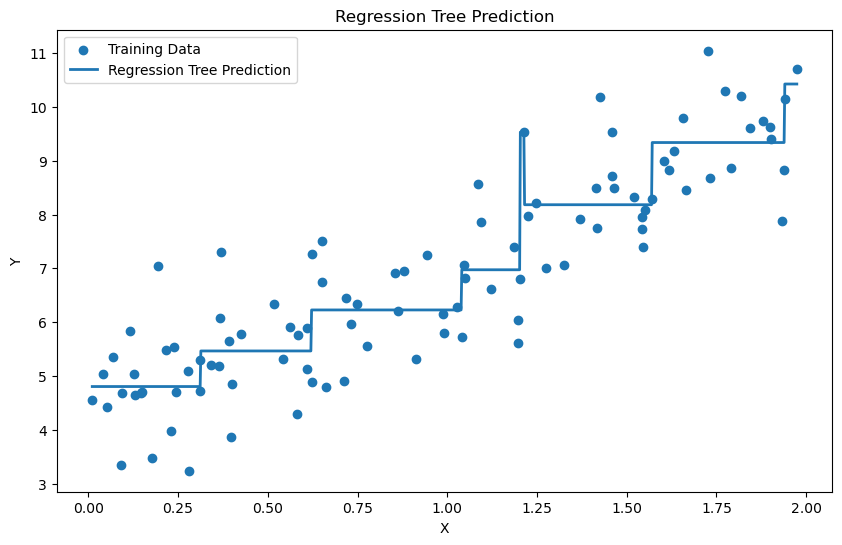

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Sort feature values for a clean plot
x_plot = np.linspace(
    x[:, 0].min(),
    x[:, 0].max(),
    1000
).reshape(-1, 1)

predictions = []

for point in x_plot:

    nid = root_node[0]

    while True:

        feature = tree[nid]["feature"]

        if feature is not None:

            threshold = tree[nid]["threshold"]

            if point[feature] <= threshold:
                nid = tree[nid]["children"][0]
            else:
                nid = tree[nid]["children"][1]

        else:
            predictions.append(tree[nid]["pred"])
            break

predictions = np.array(predictions)

# Plot original data
plt.figure(figsize=(10,6))

plt.scatter(
    x[:,0],
    y,
    label="Training Data"
)

# Plot tree prediction
plt.plot(
    x_plot[:,0],
    predictions,
    linewidth=2,
    label="Regression Tree Prediction"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Tree Prediction")
plt.legend()

plt.show()

In [14]:
tree,root_node

({2505958816336: {'feature': 0,
   'ig': np.float64(2.3361005207533037),
   'children': [2505960410544, 2505960419760],
   'threshold': np.float64(1.2022300234864176),
   'pred': None},
  2505960410544: {'feature': 0,
   'ig': np.float64(0.46883163026747576),
   'children': [2505960417840, 2505960422832],
   'threshold': np.float64(0.6219646434313244),
   'pred': None},
  2505960419760: {'feature': 0,
   'ig': np.float64(0.3611335666392158),
   'children': [2505960697136, 2505960700784],
   'threshold': np.float64(1.5703519227860272),
   'pred': None},
  2505960417840: {'feature': 0,
   'ig': np.float64(0.1073290913070275),
   'children': [2505960700208, 2505960700400],
   'threshold': np.float64(0.31203728088487304),
   'pred': None},
  2505960422832: {'feature': 0,
   'ig': np.float64(0.12389284386348842),
   'children': [2505960687920, 2505960687632],
   'threshold': np.float64(1.0401360423556216),
   'pred': None},
  2505960697136: {'feature': 0,
   'ig': np.float64(0.0955480892181